# COMP6001 Assignment 1
## Image Deblurring and Object Detection

**Student Name:** Ibrahim  
**Student ID:** a1986169  
**Course:** COMP6001  

### Objective
We investigate the effect of motion blur on object detection and evaluate whether image restoration improves object detection performance.

In [2]:
!pip install opencv-python matplotlib scikit-image pandas tqdm

   ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
   - -------------------------------------- 0.5/12.8 MB 8.5 MB/s eta 0:00:02
   -- ------------------------------------- 0.8/12.8 MB 3.4 MB/s eta 0:00:04
   ---- ----------------------------------- 1.6/12.8 MB 2.6 MB/s eta 0:00:05
   ----------- ---------------------------- 3.7/12.8 MB 4.4 MB/s eta 0:00:03
   ----------------- ---------------------- 5.5/12.8 MB 5.3 MB/s eta 0:00:02
   ------------------------ --------------- 7.9/12.8 MB 6.2 MB/s eta 0:00:01
   ------------------------------- -------- 10.2/12.8 MB 7.0 MB/s eta 0:00:01
   ---------------------------------------  12.6/12.8 MB 7.7 MB/s eta 0:00:01
   ---------------------------------------- 12.8/12.8 MB 7.4 MB/s eta 0:00:00



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import os
import cv2
import time
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from tqdm import tqdm
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

print("Libraries loaded successfully")

Libraries loaded successfully


In [4]:
# Check GPU availability (optional but good for report)
import torch
print("Torch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

Torch version: 2.6.0+cpu
GPU available: False


In [10]:
import os

# Set base path (one folder up from notebooks)
base_path = ".."

blurred_path = os.path.join(base_path, "data", "blurred")
sharp_path = os.path.join(base_path, "data", "sharp")
deblurred_path = os.path.join(base_path, "data", "deblurred")
output_path = os.path.join(base_path, "outputs")

print("Blurred path:", blurred_path)
print("Sharp path:", sharp_path)

Blurred path: ..\data\blurred
Sharp path: ..\data\sharp


In [11]:
blurred_images = sorted(os.listdir(blurred_path))
sharp_images = sorted(os.listdir(sharp_path))

print("Blurred images:", len(blurred_images))
print("Sharp images:", len(sharp_images))

Blurred images: 100
Sharp images: 100


In [13]:
print("First 10 blurred files:")
for i in range(10):
    print(blurred_images[i])

print("\nFirst 10 sharp files:")
for i in range(10):
    print(sharp_images[i])

First 10 blurred files:
84.png
85.png
86.png
87.png
88.png
9.png
914.png
915.png
916.png
917.png

First 10 sharp files:
88.png
880.png
89.png
9.png
90.png
91.png
914.png
915.png
916.png
917.png


In [18]:
gopro_train_blur = r"C:\Users\iftek\Downloads\archive (4)\Gopro\train\blur"
gopro_train_sharp = r"C:\Users\iftek\Downloads\archive (4)\Gopro\train\sharp"

print("Blur folder exists:", os.path.exists(gopro_train_blur))
print("Sharp folder exists:", os.path.exists(gopro_train_sharp))

Blur folder exists: True
Sharp folder exists: True


In [19]:
all_blur = sorted(os.listdir(gopro_train_blur))
all_sharp = sorted(os.listdir(gopro_train_sharp))

print("Blur count:", len(all_blur))
print("Sharp count:", len(all_sharp))
print("First 10 blur:", all_blur[:10])
print("First 10 sharp:", all_sharp[:10])

matched_files = [f for f in all_blur if os.path.exists(os.path.join(gopro_train_sharp, f))]
print("Matched files:", len(matched_files))
print("First 10 matched:", matched_files[:10])

Blur count: 2103
Sharp count: 2103
First 10 blur: ['0.png', '1.png', '10.png', '100.png', '1000.png', '1001.png', '1002.png', '1003.png', '1004.png', '1005.png']
First 10 sharp: ['0.png', '1.png', '10.png', '100.png', '1000.png', '1001.png', '1002.png', '1003.png', '1004.png', '1005.png']
Matched files: 2103
First 10 matched: ['0.png', '1.png', '10.png', '100.png', '1000.png', '1001.png', '1002.png', '1003.png', '1004.png', '1005.png']


In [20]:
import shutil

for f in os.listdir(blurred_path):
    os.remove(os.path.join(blurred_path, f))

for f in os.listdir(sharp_path):
    os.remove(os.path.join(sharp_path, f))

max_images = 100
selected_files = matched_files[:max_images]

for filename in selected_files:
    shutil.copy(
        os.path.join(gopro_train_blur, filename),
        os.path.join(blurred_path, filename)
    )
    shutil.copy(
        os.path.join(gopro_train_sharp, filename),
        os.path.join(sharp_path, filename)
    )

print("Copied matched pairs:", len(selected_files))
print("First 10 copied files:", selected_files[:10])

Copied matched pairs: 100
First 10 copied files: ['0.png', '1.png', '10.png', '100.png', '1000.png', '1001.png', '1002.png', '1003.png', '1004.png', '1005.png']


In [21]:
blurred_images = sorted(os.listdir(blurred_path))
sharp_images = sorted(os.listdir(sharp_path))

print("Blurred images:", len(blurred_images))
print("Sharp images:", len(sharp_images))
print("First 10 blurred:", blurred_images[:10])
print("First 10 sharp:", sharp_images[:10])

Blurred images: 100
Sharp images: 100
First 10 blurred: ['0.png', '1.png', '10.png', '100.png', '1000.png', '1001.png', '1002.png', '1003.png', '1004.png', '1005.png']
First 10 sharp: ['0.png', '1.png', '10.png', '100.png', '1000.png', '1001.png', '1002.png', '1003.png', '1004.png', '1005.png']


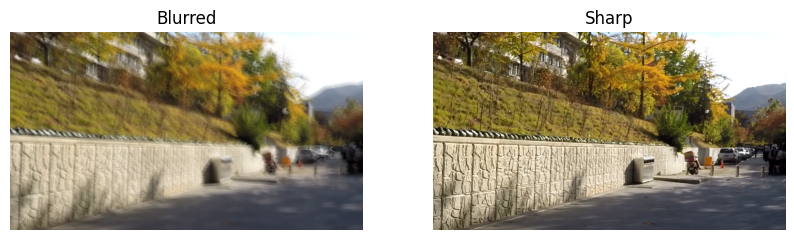

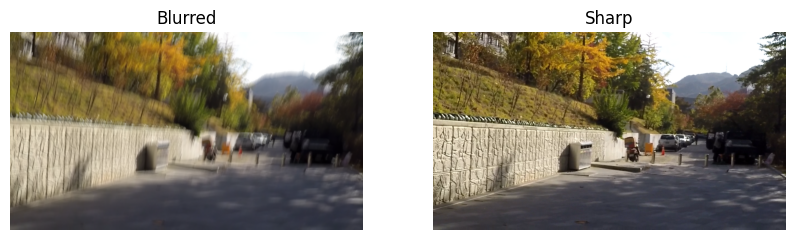

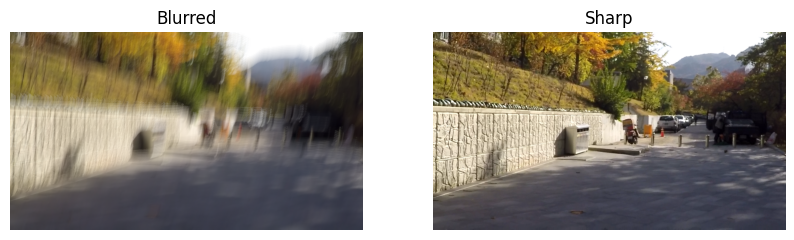

In [22]:
for i in range(3):
    filename = blurred_images[i]

    b_img = cv2.imread(os.path.join(blurred_path, filename))
    s_img = cv2.imread(os.path.join(sharp_path, filename))

    b_img = cv2.cvtColor(b_img, cv2.COLOR_BGR2RGB)
    s_img = cv2.cvtColor(s_img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(b_img)
    plt.title("Blurred")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(s_img)
    plt.title("Sharp")
    plt.axis("off")

    plt.show()

In [12]:
import cv2
import matplotlib.pyplot as plt

for i in range(3):
    filename = blurred_images[i]

    b_img = cv2.imread(os.path.join(blurred_path, filename))
    s_img = cv2.imread(os.path.join(sharp_path, filename))

    b_img = cv2.cvtColor(b_img, cv2.COLOR_BGR2RGB)
    s_img = cv2.cvtColor(s_img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.imshow(b_img)
    plt.title("Blurred")

    plt.subplot(1,2,2)
    plt.imshow(s_img)
    plt.title("Sharp")

    plt.show()

error: OpenCV(4.11.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cv::cvtColor'
